In [40]:
# Imports
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [41]:
# Exploratory analysis
bike_sharing = pd.read_csv("../data/day.csv")

bike_sharing["temp_celsius"] = bike_sharing["temp"] * 47 - 8
bike_sharing["atemp_celsius"] = bike_sharing["atemp"] * 47 - 8

bike_sharing.dropna()
bike_sharing.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,temp_celsius,atemp_celsius
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,8.175849,9.090375
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,9.083466,8.625733
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,1.229108,0.902035
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,1.400000,1.969734
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,2.666979,2.775690


In [42]:
bike_sharing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   instant        731 non-null    int64  
 1   dteday         731 non-null    object 
 2   season         731 non-null    int64  
 3   yr             731 non-null    int64  
 4   mnth           731 non-null    int64  
 5   holiday        731 non-null    int64  
 6   weekday        731 non-null    int64  
 7   workingday     731 non-null    int64  
 8   weathersit     731 non-null    int64  
 9   temp           731 non-null    float64
 10  atemp          731 non-null    float64
 11  hum            731 non-null    float64
 12  windspeed      731 non-null    float64
 13  casual         731 non-null    int64  
 14  registered     731 non-null    int64  
 15  cnt            731 non-null    int64  
 16  temp_celsius   731 non-null    float64
 17  atemp_celsius  731 non-null    float64
dtypes: float64

In [43]:
# Model

bike_sharing_poly = bike_sharing.copy()
bike_sharing_poly['atemp'] = bike_sharing_poly['atemp'] - bike_sharing_poly['atemp'].mean()
bike_sharing_poly['hum'] = bike_sharing_poly['hum'] - bike_sharing_poly['hum'].mean()
bike_sharing_poly['windspeed'] = bike_sharing_poly['windspeed'] - bike_sharing_poly['windspeed'].mean()
for col in ["atemp", "hum", "windspeed"]:
    bike_sharing_poly[f"{col}_sq"] = bike_sharing_poly[col] ** 2

features = ["season" ,"yr", "mnth", "holiday", "weekday", "workingday", "weathersit", "atemp", "hum", "windspeed", "atemp_sq", "hum_sq", "windspeed_sq"]

X = sm.add_constant(bike_sharing_poly[features])
y = np.log(bike_sharing_poly["cnt"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = sm.OLS(y_train, X_train).fit()
fitted = model.fittedvalues

resid = y_train - fitted
fitted_test = model.predict(X_test)

# Colinearity
vif_data = pd.DataFrame()
vif_data["variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

        variable        VIF
0          const  26.302280
1         season   3.576572
2             yr   1.042599
3           mnth   3.392199
4        holiday   1.084878
5        weekday   1.021983
6     workingday   1.080398
7     weathersit   1.994645
8          atemp   1.252948
9            hum   2.089595
10     windspeed   1.420252
11      atemp_sq   1.163701
12        hum_sq   1.262020
13  windspeed_sq   1.286569


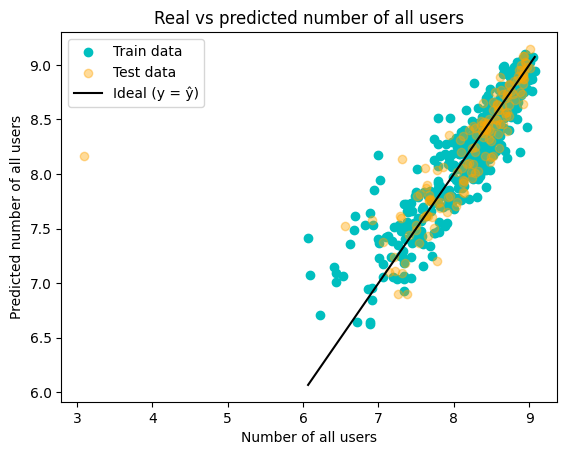

In [44]:
plt.scatter(y_train, fitted, color="c", label="Train data")
plt.scatter(y_test, fitted_test, color="orange", alpha=0.4, label="Test data")
plt.xlabel("Number of all users")
plt.ylabel("Predicted number of all users")
plt.title("Real vs predicted number of all users")
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color="k", label="Ideal (y = ŷ)")
plt.legend()
plt.show()

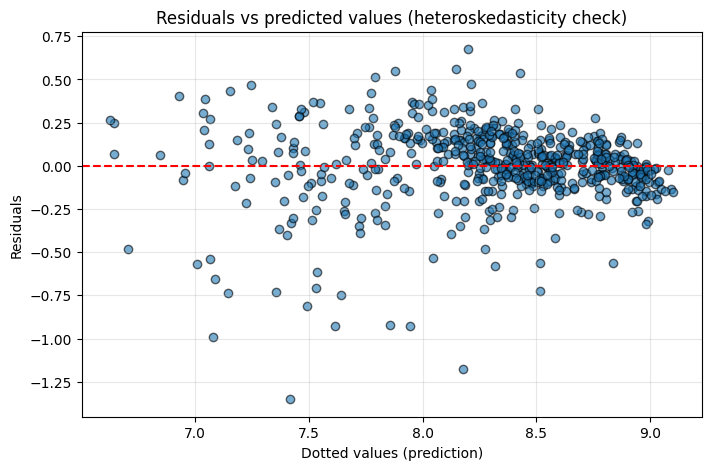

In [45]:
plt.figure(figsize=(8, 5))
plt.scatter(fitted, resid, alpha=0.6, edgecolors="k")
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Dotted values (prediction)")
plt.ylabel("Residuals")
plt.title("Residuals vs predicted values (heteroskedasticity check)")
plt.grid(True, alpha=0.3)
plt.show()

In [46]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.831
Method:                 Least Squares   F-statistic:                     222.2
Date:                Mon, 27 Jul 2026   Prob (F-statistic):          2.94e-213
Time:                        08:25:23   Log-Likelihood:                 43.720
No. Observations:                 584   AIC:                            -59.44
Df Residuals:                     570   BIC:                             1.739
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            8.1492      0.048    169.400      0.000       8.055       8.244
season           0.1568      0.017      9.271      0.000       0.124       0.190
yr               0.4508      0.019     23.421      0.000       0.413       0.489
mnth            -0.0185      0.005     -3.493      0.001      -0.029      -0.008
holiday         -0.1512      0.062     -2.447      0.015      -0.273      -0.030
weekday          0.0140      0.005      2.974      0.003       0.005       0.023
workingday       0.0647      0.021      3.122      0.002       0.024       0.105
weathersit      -0.1521      0.024     -6.254      0.000      -0.200      -0.104
atemp            1.6227      0.066     24.712      0.000       1.494       1.752
hum             -0.5819      0.095     -6.102      0.000      -0.769      -0.395
windspeed       -0.4224      0.146     -2.886      0.004      -0.710      -0.135
atemp_sq        -6.1852      0.379    -16.338      0.000      -6.929      -5.442
hum_sq          -2.4285      0.372     -6.525      0.000      -3.160      -1.697
windspeed_sq    -2.3132      1.211     -1.910      0.057      -4.692       0.066
==============================================================================
Omnibus:                      203.554   Durbin-Watson:                   1.885
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1021.320
Skew:                          -1.475   Prob(JB):                    1.67e-222
Kurtosis:                       8.768   Cond. No.                     1.09e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.09e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""